In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [14]:
df = pd.read_csv("/content/creditcard.csv")
df = df.rename(columns={"Class": "fraud"})
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,fraud
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
print(df["fraud"].value_counts())
print(df["fraud"].value_counts(normalize=True) * 100)

fraud
0    284315
1       492
Name: count, dtype: int64
fraud
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [16]:
X = df.drop("fraud", axis=1)
y = df["fraud"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [18]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(y_train_res.value_counts())

fraud
0    199020
1    199020
Name: count, dtype: int64


In [19]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(y_prob_xgb[:20])

[0.00088799 0.01060327 0.05870557 0.00330071 0.01356733 0.00189363
 0.03019444 0.00422992 0.01464037 0.00118105 0.00127401 0.01305083
 0.00068822 0.0004418  0.0038369  0.00060987 0.00485257 0.00514834
 0.00193252 0.01929374]


In [21]:
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", auc_xgb)

XGBoost ROC-AUC: 0.9680343893926168


In [22]:
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", auc_xgb)

XGBoost ROC-AUC: 0.9680343893926168


In [23]:
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance)

V14       0.481085
V10       0.145863
V17       0.051956
V4        0.044503
V12       0.031790
V8        0.018888
V5        0.016647
V1        0.016330
V13       0.015439
V28       0.013012
V3        0.012948
V7        0.012828
V9        0.011567
V18       0.011320
V21       0.011134
V11       0.011019
V15       0.010638
V22       0.010036
V23       0.008114
V16       0.007758
V26       0.007634
V25       0.007519
Time      0.007184
V27       0.006886
V2        0.006714
V24       0.006186
V20       0.005309
V19       0.004971
V6        0.004723
Amount    0.000000
dtype: float32


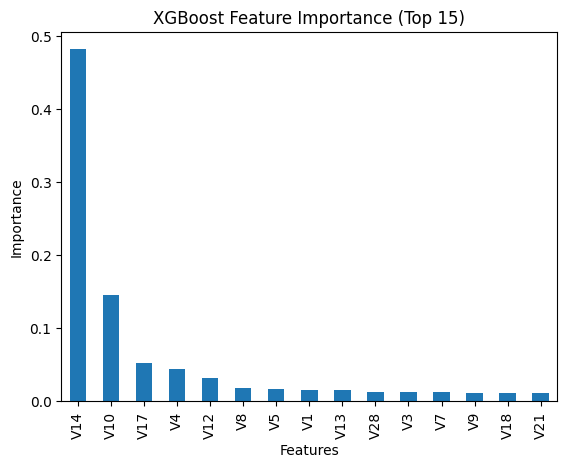

In [24]:
importance.head(15).plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance (Top 15)")
plt.show()